# Embedding playground

Build the **conditioning vector yourself** instead of picking a device row:
morph between two devices, push along principal components of the learned
embedding table, feed the table mean — or feed **no conditioning at all** and
hear the model's default behaviour.

- **Condition** — how the vector is built:
  *device morph* (base/target + PC offsets), *mean embedding* (table average
  + PC offsets), or *no conditioning* (all-zero embedding: every FiLM layer
  falls back to its learned bias — the model with zero device information).
- **Base / Target + Morph α** — linear interpolation `(1−α)·base + α·target`
  (the slider goes past [0, 1] for extrapolation).
- **PC1…PC8** — offsets along the top principal components of the embedding
  table, in units of the table's std on each component.
- Readouts per Run: render speed, vector norm vs the table, nearest table
  devices by cosine, and ESR against the base/target real renders when
  available.
- **Measurement bench** (bottom of the notebook) — test-signal
  characterization of the selected condition: linear voicing
  (magnitude/phase/group delay from a low-level log sweep), Farina
  harmonic-order separation at drive levels, static transfer curve, and
  THD vs input level.

Same conventions as `emulate_demo`: **open-amp3000** kernel (Python 3.10),
CPU-only, checkpoint temp-copied so it is safe to use while training is still
writing new checkpoints.

In [1]:
import os, shutil, tempfile
from pathlib import Path

# run from the repo root so the config's relative data paths resolve
if not Path('configs').is_dir() and (Path.cwd().parent / 'configs').is_dir():
    os.chdir(Path.cwd().parent)
print('cwd:', Path.cwd())

import numpy as np
import pandas as pd
import torch

from openamp.core.config import load_config
from openamp.dsp.audio import audio_info, seek_read
from openamp.emulate.evaluate import load_model

RUN_DIR = Path('results/emulate/wavenet_a2')   # <- change to play with other runs

cfg = load_config()
with tempfile.TemporaryDirectory() as td:
    shutil.copy(RUN_DIR / 'checkpoint.pt', Path(td) / 'checkpoint.pt')
    model, ck = load_model(Path(td), 'cpu')
model.eval()
R = int(ck['receptive_field'])
ID2ROW = ck['id_to_idx']
ROW2ID = {row: dev for dev, row in ID2ROW.items()}

# frozen copy of the learned embedding table -- the playground never mutates it
EMB = model.embedding.weight.detach().cpu().numpy().copy()   # [N_devices, E]
MU = EMB.mean(axis=0)
_U, _S, _Vt = np.linalg.svd(EMB - MU, full_matrices=False)
PCS = _Vt                                    # rows = principal directions
COMP_STD = _S / np.sqrt(len(EMB) - 1)        # table std along each component
EVR = _S ** 2 / (_S ** 2).sum()              # explained-variance ratio

# device catalog (make/model/gain labels), restricted to the checkpoint's table
cat = pd.read_parquet('data/manifests/manifest.parquet').drop_duplicates('device_id')
cat = cat[cat['device_id'].isin(ID2ROW)].set_index('device_id')

# corpus files (these have real renders to compare against)
corpus = pd.read_parquet(cfg.corpus_manifest_path)
corpus = corpus.sort_values(['split', 'file_id'])

print(f"run: {ck['name']}  epoch={ck['epoch']}  val_esr={ck['val_esr']:.4f}")
print(f"embedding table: {EMB.shape[0]} devices x {EMB.shape[1]} dims   "
      f"top-8 PCs explain {100 * EVR[:8].sum():.0f}% of table variance")

cwd: /m/home/home3/37/thieun1/unix/Project/Open-Amp3000
run: wavenet_a2  epoch=76  val_esr=0.1198
embedding table: 405 devices x 128 dims   top-8 PCs explain 33% of table variance


In [2]:
from time import perf_counter

from scipy.signal import resample_poly
from torch import nn


def read_clean_window(file_id: str, split: str, start_s: float, dur_s: float):
    """Clean corpus audio [start, start+dur) with R samples of real left-context."""
    path = cfg.clean_split_dir(split) / f'{file_id}.{cfg.output_format}'
    n = audio_info(path)[0]
    clip = int(dur_s * cfg.sample_rate)
    c = min(int(start_s * cfg.sample_rate), max(n - clip, 0))
    clip = min(clip, n - c)
    s, pad = c - R, 0
    if s < 0:
        pad, s = -s, 0
    x = seek_read(path, s, R + clip - pad)
    if pad:
        x = np.concatenate([np.zeros(pad, np.float32), x])
    return x, c, clip


def read_target_window(device_id: int, file_id: str, c: int, clip: int):
    path = cfg.device_render_dir(device_id) / f'{file_id}.{cfg.output_format}'
    if not path.is_file():
        return None
    try:
        return seek_read(path, c, clip)
    except Exception as e:                      # rare libsndfile seek quirk
        print(f'(no target: {e!r})')
        return None


def read_external(path: str, start_s: float, dur_s: float):
    """Any wav/flac: mono-mix, resample to 48 kHz, cut the window, zero context."""
    import soundfile as sf
    x, sr = sf.read(path, dtype='float32')
    if x.ndim > 1:
        x = x.mean(axis=1)
    if sr != cfg.sample_rate:
        x = resample_poly(x, cfg.sample_rate, sr).astype(np.float32)
    c = int(start_s * cfg.sample_rate)
    x = x[c:c + int(dur_s * cfg.sample_rate)]
    peak = np.abs(x).max()
    if peak > 0:                                # match corpus headroom roughly
        x = 0.5 * x / peak
    return np.concatenate([np.zeros(R, np.float32), x]), None, len(x)


class _FixedEmb(nn.Module):
    """Stand-in for ``model.embedding``: returns one fixed vector for any index."""

    def __init__(self, vec):
        super().__init__()
        self.register_buffer('vec', torch.as_tensor(np.ascontiguousarray(vec),
                                                    dtype=torch.float32))

    def forward(self, idx):
        return self.vec.unsqueeze(0).expand(idx.shape[0], -1)


@torch.no_grad()
def emulate_with_embedding(clean_with_ctx: np.ndarray, emb: np.ndarray) -> np.ndarray:
    """Run the emulator conditioned on an arbitrary embedding vector.

    Arch-agnostic: FiLMTCN and FiLMWaveNet both look conditioning up as
    ``self.embedding(device_idx)``, so the table is swapped for the fixed
    vector for the duration of the forward pass, then restored.
    """
    x = torch.from_numpy(clean_with_ctx)[None]
    table = model.embedding
    model.embedding = _FixedEmb(emb)
    try:
        y = model(x, torch.zeros(1, dtype=torch.long))
    finally:
        model.embedding = table
    return y[0, 0, R:].numpy()


def esr(pred, target):
    return float(((pred - target) ** 2).sum() / ((target ** 2).sum() + 1e-8))


def nearest_devices(e: np.ndarray, k: int = 3):
    """Table devices most cosine-similar to embedding ``e``."""
    sims = (EMB @ e) / (np.linalg.norm(EMB, axis=1) * np.linalg.norm(e) + 1e-12)
    return [(ROW2ID[int(r)], float(sims[r])) for r in np.argsort(-sims)[:k]]

print('engine ready')

engine ready


In [3]:
import ipywidgets as W
from IPython.display import Audio, display

N_PC = 8


def _dev_label(d):
    r = cat.loc[d]
    return f"{d:4d} · {r['make']} {r['model']} ({r.get('gain_bucket', '?')})"


_dev_opts = [(_dev_label(d), d) for d in sorted(ID2ROW)]
mode_dd = W.Dropdown(
    options=[('device morph (base/target + PCs)', 'morph'),
             ('mean embedding — average device (+ PCs)', 'mean'),
             ('no conditioning — zero embedding', 'zero')],
    description='Condition')
base_dd = W.Dropdown(options=_dev_opts, description='Base')
tgt_dd = W.Dropdown(options=_dev_opts, index=1, description='Target')
morph_sl = W.FloatSlider(value=0.0, min=-0.5, max=1.5, step=0.05,
                         description='Morph α', readout_format='.2f')
pc_sliders = [W.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1,
                            description=f'PC{i + 1} ({100 * EVR[i]:.0f}%)',
                            readout_format='.1f')
              for i in range(N_PC)]
reset_btn = W.Button(description='Reset vector')

file_dd = W.Dropdown(options=[(f"{r.file_id} · {r.split} · {r.duration_s:.0f}s",
                               (r.file_id, r.split))
                              for r in corpus.itertuples(index=False)],
                     description='Audio')
ext_txt = W.Text(value='', placeholder='(optional) /path/to/your_guitar_DI.wav',
                 description='External', layout=W.Layout(width='60%'))
start_sl = W.FloatSlider(value=0.0, min=0.0, max=60.0, step=0.5, description='Start s')
dur_sl = W.FloatSlider(value=8.0, min=2.0, max=20.0, step=1.0, description='Length s')
run_btn = W.Button(description='Run', button_style='primary')
out = W.Output()


def current_embedding():
    """morph: (1−α)·base + α·target + ΣPC   mean: MU + ΣPC   zero: 0"""
    if mode_dd.value == 'zero':
        return np.zeros(EMB.shape[1], np.float32)
    if mode_dd.value == 'mean':
        e = MU.copy()
    else:
        a = EMB[ID2ROW[base_dd.value]]
        b = EMB[ID2ROW[tgt_dd.value]]
        e = (1.0 - morph_sl.value) * a + morph_sl.value * b
    for i, sl in enumerate(pc_sliders):
        if sl.value:
            e = e + sl.value * COMP_STD[i] * PCS[i]
    return e.astype(np.float32)


def _sync_mode(*_):
    is_morph = mode_dd.value == 'morph'
    base_dd.disabled = tgt_dd.disabled = morph_sl.disabled = not is_morph
    for sl in pc_sliders:
        sl.disabled = mode_dd.value == 'zero'


def on_reset(_):
    morph_sl.value = 0.0
    for sl in pc_sliders:
        sl.value = 0.0


def on_run(_):
    out.clear_output()
    with out:
        e = current_embedding()
        want_refs = mode_dd.value == 'morph'
        if ext_txt.value.strip():
            x, c, clip = read_external(ext_txt.value.strip(),
                                       start_sl.value, dur_sl.value)
            src = Path(ext_txt.value).name
            base_t = tgt_t = None
        else:
            fid, split = file_dd.value
            x, c, clip = read_clean_window(fid, split, start_sl.value, dur_sl.value)
            src = f'{fid} ({split})'
            base_t = (read_target_window(base_dd.value, fid, c, clip)
                      if want_refs else None)
            tgt_t = (read_target_window(tgt_dd.value, fid, c, clip)
                     if want_refs and morph_sl.value else None)
        t0 = perf_counter()
        pred = emulate_with_embedding(x, e)
        dt = perf_counter() - t0
        audio_s = clip / cfg.sample_rate

        if mode_dd.value == 'zero':
            print('condition: none — zero embedding '
                  '(each FiLM layer runs on its learned bias alone)')
        elif mode_dd.value == 'mean':
            print('condition: mean embedding (average of the device table)')
        else:
            print(f'base   {_dev_label(base_dd.value)}')
            if morph_sl.value:
                print(f'target {_dev_label(tgt_dd.value)}   (α = {morph_sl.value:.2f})')
        if mode_dd.value != 'zero':
            offs = [f'PC{i + 1} {sl.value:+.1f}σ'
                    for i, sl in enumerate(pc_sliders) if sl.value]
            if offs:
                print('offsets  ' + '   '.join(offs))
        print(f'source {src}   |   {audio_s:.1f}s   |   '
              f'rendered in {dt:.2f}s on CPU ({audio_s / dt:.2f}× realtime)')
        norms = np.linalg.norm(EMB, axis=1)
        print(f'|e| = {np.linalg.norm(e):.3f}   '
              f'(table norms: {norms.mean():.3f} ± {norms.std():.3f})')
        if np.linalg.norm(e) > 0:
            print('nearest table devices:  '
                  + '   '.join(f'{_dev_label(d).strip()} cos={s:.3f}'
                               for d, s in nearest_devices(e)))
        if base_t is not None:
            line = f'ESR of prediction vs base render {esr(pred, base_t):.4f}'
            if tgt_t is not None:
                line += f'   vs target render {esr(pred, tgt_t):.4f}'
            print(line)

        print('\nclean input:')
        display(Audio(x[R:], rate=cfg.sample_rate, normalize=False))
        if base_t is not None:
            print('real render — base device:')
            display(Audio(base_t, rate=cfg.sample_rate, normalize=False))
        if tgt_t is not None:
            print('real render — target device:')
            display(Audio(tgt_t, rate=cfg.sample_rate, normalize=False))
        print('prediction — custom embedding:')
        display(Audio(np.clip(pred, -1, 1), rate=cfg.sample_rate, normalize=False))


mode_dd.observe(_sync_mode, 'value')
_sync_mode()
reset_btn.on_click(on_reset)
run_btn.on_click(on_run)

display(W.VBox([
    W.HTML('<b>Conditioning vector</b> — e = (1−α)·base + α·target + Σ slider·σ·PC, '
           'or the table mean, or nothing at all'),
    mode_dd, base_dd, tgt_dd, morph_sl,
    W.GridBox(pc_sliders,
              layout=W.Layout(grid_template_columns='repeat(2, 420px)')),
    reset_btn,
    W.HTML('<b>Audio source</b>'),
    file_dd, ext_txt, W.HBox([start_sl, dur_sl]),
    run_btn, out,
]))

**Notes**

- *Condition* modes: **device morph** builds the vector from two table rows;
  **mean embedding** starts from the table average `MU` (the classic
  mean ± σ·PC exploration); **no conditioning** feeds an all-zero embedding,
  so each FiLM layer applies only its learned bias — the model's "default
  amp" with zero device information. At init that bias was scale 1 / shift 0
  (a plain unconditioned WaveNet), but it *is* trained, so what you hear is a
  learned neutral, not a bypass. Widgets that a mode ignores are greyed out.
- *Morph α* interpolates linearly between the two table rows (α < 0 and α > 1
  extrapolate past them). Training only ever used exact table rows, so
  everything in between is generalization — artifacts there are findings, not
  bugs.
- *PC sliders* move along principal components of the **learned** table, in
  units of the table's std on that component (±3 spans roughly the whole
  device population). Listen for which PCs encode gain, brightness, etc.
- *|e|*: the FiLM scale/shift are linear in the embedding, so vectors far
  outside the table's norm range mostly saturate the modulation — expect
  volume/fizz changes rather than genuinely new tones.
- *nearest table devices* is cosine similarity between your vector and the
  table — a readout of where the custom vector landed (skipped for the zero
  vector, where cosine is undefined).
- With a corpus file in morph mode, the base (and, when α ≠ 0, target) real
  renders are played for reference, plus the prediction's plain ESR against
  each. At α = 0 with all sliders at 0 the prediction is exactly
  `emulate_demo`'s for the base device.
- Full manual control: call `emulate_with_embedding(x, e)` from a fresh cell
  with any length-`embedding_dim` numpy vector (e.g. a row of `EMB`, `MU`, or
  something entirely synthetic).
- Re-run **setup** to pick up the latest best checkpoint mid-training; any
  `RUN_DIR`/arch works (TCN or WaveNet) — only `model.embedding` is assumed.

## Measurement bench — EQ character vs distortion character

The cells below probe the emulator like an amp on a test bench, **through
whatever Condition is currently selected in the panel above** (a device, a
morph, the mean, or zero = the model's default). Run the ui cell first;
re-run any bench cell after changing the condition. Level is the lever that
separates the two characters: low reveals the linear filters, high reveals
the nonlinearity.

- **Linear voicing** — a log sweep at two low levels (20 dB apart),
  deconvolved into small-signal magnitude, phase, and group delay. This is
  the tone-stack + cab voicing, and the phase/group delay it carries is real
  (minimum-phase filters). The two-level overlay is the linearity check: if
  the traces don't match, the distortion stage isn't dormant yet — go lower.
  One neural-model wrinkle: a ReLU net may have **no strictly linear
  region** (its kinks sit at the operating point), so expect a small
  residual deviation — a couple of dB is as linear as it gets; 8+ dB means
  you're still driving it. High-gain devices need lower levels than clean
  ones, and the zero-conditioning "default" tends to stay level-dependent
  all the way down.
- **Harmonic structure vs frequency** (Farina) — the same sweep at real drive
  levels; deconvolution separates each distortion order into its own impulse
  response, showing *which* harmonics dominate and how that changes across
  frequency.
- **Static transfer curve + THD vs level** — a slow amplitude-ramped sine
  plotted output-vs-input (symmetric clipping → odd harmonics; asymmetric →
  even; the knee shape is right there in the curvature — and the smear/loops
  are memory around the nonlinearity, not measurement error), plus harmonic
  levels and THD as the input level sweeps up: how hard before it breaks up,
  and how gracefully.

Two caveats. The small-signal voicing is **not** the effective spectral tilt
at playing levels — distortion fills in harmonics and the post-nonlinearity
EQ reshapes them — so read these as complementary views, never one number.
And the model only ever saw corpus-level inputs (≈ −18 dBFS RMS): very hot
levels probe extrapolation, not learned amp behaviour.

In [80]:
# Measurement-bench engine: test signals, Farina deconvolution, helpers.
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

SR = cfg.sample_rate
F1, F2, T_SWEEP = 20.0, 20000.0, 8.0
SWEEP_RATE = T_SWEEP / np.log(F2 / F1)       # 'L' in Farina's formulation

# validated categorical palette, fixed slot order; color follows the entity:
# harmonic order n keeps its color across every bench figure
C = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a']
GRID = dict(color='0.88', linewidth=0.6)


def render_signal(sig: np.ndarray, e: np.ndarray) -> np.ndarray:
    """Model output for ``sig``, sample-aligned (R zeros of left context)."""
    x = np.concatenate([np.zeros(R, np.float32), sig.astype(np.float32)])
    return emulate_with_embedding(x, e)


def log_sweep(amp: float, T: float = T_SWEEP, f1: float = F1, f2: float = F2):
    """Farina log sweep at peak ``amp`` (+0.5 s tail room) and its inverse filter."""
    t = np.arange(int(T * SR)) / SR
    L = T / np.log(f2 / f1)
    x = np.sin(2 * np.pi * f1 * L * np.expm1(t / L))
    nf = int(0.02 * SR)                      # short fades against clicks
    x[:nf] *= np.hanning(2 * nf)[:nf]
    x[-nf:] *= np.hanning(2 * nf)[nf:]
    x = (amp * x).astype(np.float32)
    inv = x[::-1] * np.exp(-t / L)           # -6 dB/oct amplitude compensation
    return np.concatenate([x, np.zeros(int(0.5 * SR), np.float32)]), inv


def deconvolve(y: np.ndarray, sweep: np.ndarray, inv: np.ndarray):
    """System IR in gain units and the sample index of the linear response.

    Normalizing by the sweep's own deconvolution peak makes the linear IR's
    spectrum read directly as output/input transfer; harmonic-order IRs land
    at t0 - SWEEP_RATE·ln(n) seconds (Farina).
    """
    N = 1 << int(np.ceil(np.log2(len(y) + len(inv))))
    ir = np.fft.irfft(np.fft.rfft(y, N) * np.fft.rfft(inv, N), N)
    ref = np.fft.irfft(np.fft.rfft(sweep, N) * np.fft.rfft(inv, N), N)
    t0 = int(np.argmax(np.abs(ref)))
    return ir / ref[t0], t0


def linear_ir(ir: np.ndarray, t0: int, pre: int = 64, post: int = 8192):
    """Linear IR with t0 rotated to index 0 so phase carries no false delay."""
    seg = ir[t0 - pre:t0 + post].copy()
    seg[-post // 4:] *= np.hanning(post // 2)[post // 4:]   # fade the tail
    return np.roll(seg, -pre)


def harmonic_ir(ir: np.ndarray, t0: int, order: int, half: int = 2048):
    """Windowed IR of one distortion order (order 1 = the linear response)."""
    c = t0 - int(round(SWEEP_RATE * np.log(order) * SR))
    return ir[c - half:c + half] * np.hanning(2 * half)


def spectrum(seg: np.ndarray, nfft: int = 1 << 15):
    return np.fft.rfftfreq(nfft, 1 / SR), np.fft.rfft(seg, nfft)


def db(v):
    return 20 * np.log10(np.maximum(np.abs(v), 1e-12))


def condition_label():
    if mode_dd.value == 'zero':
        return 'no conditioning (zero embedding)'
    lbl = ('mean embedding' if mode_dd.value == 'mean'
           else _dev_label(base_dd.value).strip())
    if mode_dd.value == 'morph' and morph_sl.value:
        lbl += f' → {_dev_label(tgt_dd.value).strip()} (α={morph_sl.value:.2f})'
    offs = [f'PC{i + 1}{sl.value:+.1f}σ'
            for i, sl in enumerate(pc_sliders) if sl.value]
    return lbl + ('  +  ' + ' '.join(offs) if offs else '')

print('bench ready')

bench ready


In [ ]:
# Linear voicing: two low-level log sweeps (20 dB apart) -> small-signal
# magnitude, phase, and group delay via Farina deconvolution. If the two
# magnitude traces do not overlay, the model is not linear at these levels.
# NB a ReLU net may have no strictly linear region (its kinks sit at the
# operating point): a couple of dB residual is as linear as it gets.
LEVELS_DB = (-80, -60)                 # sweep peak dBFS

e = current_embedding()
print('condition:', condition_label())
t_bench = perf_counter()
H = {}
for lv in LEVELS_DB:
    sweep, inv = log_sweep(10 ** (lv / 20))
    ir, t0 = deconvolve(render_signal(sweep, e), sweep, inv)
    f, H[lv] = spectrum(linear_ir(ir, t0))

band = (f >= 40) & (f <= 15000)
dev = np.max(np.abs(db(H[LEVELS_DB[0]])[band] - db(H[LEVELS_DB[1]])[band]))
verdict = ('effectively linear' if dev < 1.0 else
           'quasi-linear; treat the voicing as approximate' if dev < 3.0 else
           'still level-dependent -- go lower')
print(f'linearity check: max |Δmag| {dev:.2f} dB between the two levels '
      f'(40 Hz-15 kHz) -> {verdict}')

mask = (f >= F1) & (f <= F2)
phase = np.unwrap(np.angle(H[LEVELS_DB[0]]))
gd = -np.gradient(phase, f) / (2 * np.pi) * 1000.0
gd = np.convolve(gd, np.ones(9) / 9, mode='same')     # light smoothing

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for lv, c in zip(LEVELS_DB, C):
    axes[0].semilogx(f[mask], db(H[lv])[mask], color=c, lw=1.6,
                     label=f'sweep @ {lv} dBFS')
axes[0].set_title('small-signal magnitude')
axes[0].set_ylabel('gain (dB)')
axes[0].set_ylim(-30, 60)              # fixed range so conditions compare
axes[0].legend()
axes[1].semilogx(f[mask], np.degrees(phase[mask]), color=C[0], lw=1.6)
axes[1].set_title('phase (unwrapped)')
axes[1].set_ylabel('degrees')
axes[2].semilogx(f[mask], gd[mask], color=C[0], lw=1.6)
g_lo, g_hi = np.percentile(gd[mask], [1, 99])
axes[2].set_ylim(g_lo - 0.2, g_hi + 0.2)
axes[2].set_title('group delay')
axes[2].set_ylabel('ms')
for ax in axes:
    ax.set_xlim(F1, F2)
    ax.set_xlabel('Hz')
    ax.grid(True, which='both', **GRID)
plt.tight_layout(); plt.show()
print(f'measured in {perf_counter() - t_bench:.1f}s')

condition: 21 · 2015 fender hot rod deluxe iii 15 hot rod deluxe - funky clean (crunch) → 21 · 2015 fender hot rod deluxe iii 15 hot rod deluxe - funky clean (crunch) (α=-0.50)  +  PC4+3.0σ


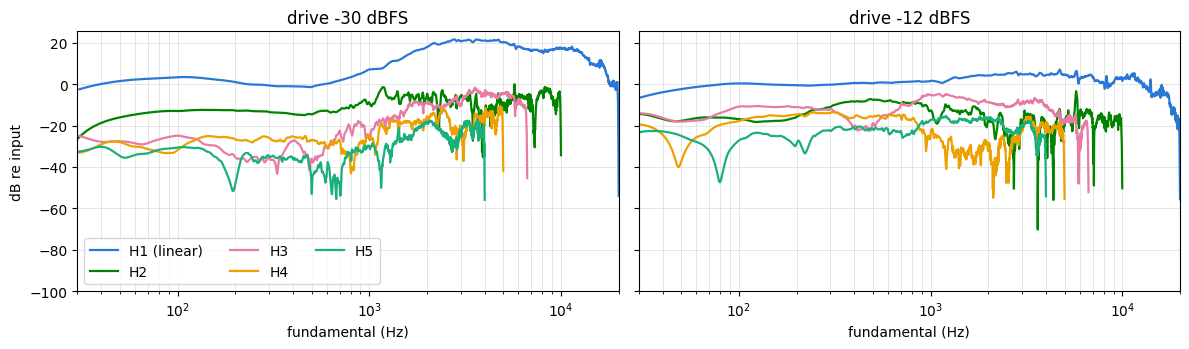

measured in 5.1s


In [82]:
# Harmonic structure vs frequency (Farina): the sweep deconvolution separates
# each distortion order into its own impulse response. Order n is plotted
# against the fundamental frequency that produced it; height = "gain" from the
# input into that harmonic. Run at two real drive levels.
DRIVES_DB = (-30, -12)                 # sweep peak dBFS: moderate / hot
N_ORDERS = 5

e = current_embedding()
print('condition:', condition_label())
t_bench = perf_counter()

fig, axes = plt.subplots(1, len(DRIVES_DB), figsize=(12, 3.6), sharey=True)
for ax, drive in zip(np.atleast_1d(axes), DRIVES_DB):
    sweep, inv = log_sweep(10 ** (drive / 20))
    ir, t0 = deconvolve(render_signal(sweep, e), sweep, inv)
    for n in range(1, N_ORDERS + 1):
        f, spec = spectrum(harmonic_ir(ir, t0, n))
        fu = f / n                     # fundamental that produced this order
        m = (fu >= 30) & (fu <= F2 / n)
        ax.semilogx(fu[m], db(spec)[m], color=C[n - 1], lw=1.6,
                    label=f'H{n}' + (' (linear)' if n == 1 else ''))
    ax.set_title(f'drive {drive} dBFS')
    ax.set_xlabel('fundamental (Hz)')
    ax.set_xlim(30, F2)
    ax.set_ylim(bottom=-100)
    ax.grid(True, which='both', **GRID)
np.atleast_1d(axes)[0].set_ylabel('dB re input')
np.atleast_1d(axes)[0].legend(ncol=3)
plt.tight_layout(); plt.show()
print(f'measured in {perf_counter() - t_bench:.1f}s')

condition: 21 · 2015 fender hot rod deluxe iii 15 hot rod deluxe - funky clean (crunch) → 21 · 2015 fender hot rod deluxe iii 15 hot rod deluxe - funky clean (crunch) (α=-0.50)  +  PC4+3.0σ


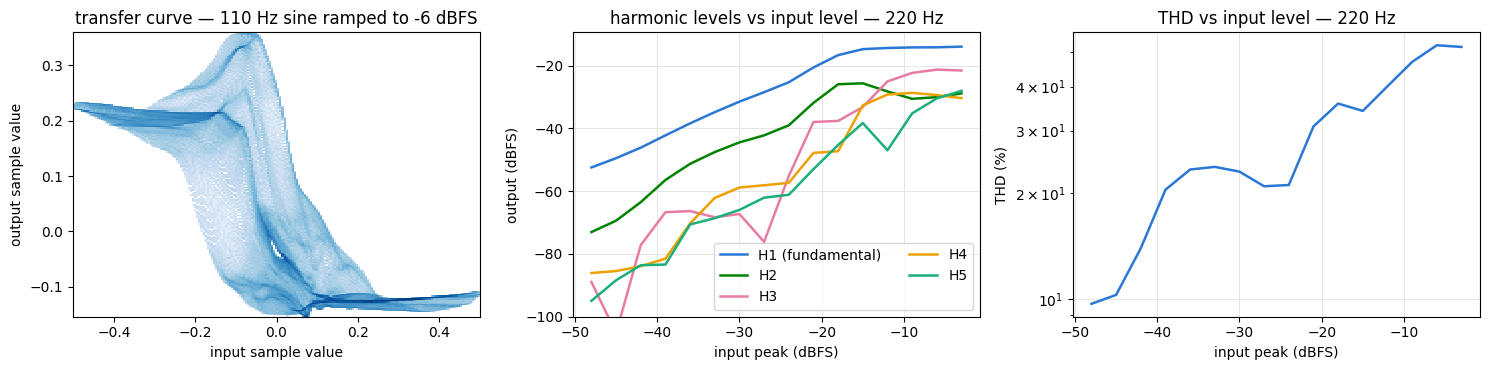

measured in 37.9s


In [83]:
# Static transfer curve (output vs input) + THD vs input level.
# The band width / open loops in the transfer plot are memory (filtering
# around the nonlinearity), not measurement error.
F_CURVE = 110.0                        # ramped transfer-curve tone (Hz)
A_CURVE = 10 ** (-6 / 20)              # ramp target: -6 dBFS peak
F_THD = 220.0                          # THD tone (Hz)
LEVELS = np.arange(-48.0, -2.9, 3.0)   # input peak dBFS
N_ORD = 5

e = current_embedding()
print('condition:', condition_label())
t_bench = perf_counter()

t = np.arange(int(4.0 * SR)) / SR
ramp = (t / t[-1] * A_CURVE * np.sin(2 * np.pi * F_CURVE * t)).astype(np.float32)
xi = ramp[R:]                          # drop the receptive-field fill-in
yo = render_signal(ramp, e)[R:]

win = np.hanning(SR // 2)
fr = np.fft.rfftfreq(len(win), 1 / SR)
kbin = [np.argmin(np.abs(fr - (n + 1) * F_THD)) for n in range(N_ORD)]
harm = np.zeros((len(LEVELS), N_ORD))
for i, lv in enumerate(LEVELS):
    a = 10 ** (lv / 20)
    sig = (a * np.sin(2 * np.pi * F_THD * np.arange(int(0.8 * SR)) / SR)).astype(np.float32)
    spec = np.abs(np.fft.rfft(render_signal(sig, e)[-len(win):] * win))
    harm[i] = [2 * spec[k - 3:k + 4].max() / win.sum() for k in kbin]
thd = 100 * np.sqrt((harm[:, 1:] ** 2).sum(1)) / np.maximum(harm[:, 0], 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist2d(xi, yo, bins=201, norm=LogNorm(), cmap='Blues')
axes[0].set_title(f'transfer curve — {F_CURVE:.0f} Hz sine ramped to -6 dBFS')
axes[0].set_xlabel('input sample value')
axes[0].set_ylabel('output sample value')
for n in range(N_ORD):
    axes[1].plot(LEVELS, db(harm[:, n]), color=C[n], lw=1.8,
                 label=f'H{n + 1}' + (' (fundamental)' if n == 0 else ''))
axes[1].set_title(f'harmonic levels vs input level — {F_THD:.0f} Hz')
axes[1].set_xlabel('input peak (dBFS)')
axes[1].set_ylabel('output (dBFS)')
axes[1].set_ylim(bottom=-100)
axes[1].legend(ncol=2)
axes[2].semilogy(LEVELS, np.maximum(thd, 1e-3), color=C[0], lw=1.8)
axes[2].set_title(f'THD vs input level — {F_THD:.0f} Hz')
axes[2].set_xlabel('input peak (dBFS)')
axes[2].set_ylabel('THD (%)')
for ax in axes[1:]:
    ax.grid(True, **GRID)
plt.tight_layout(); plt.show()
print(f'measured in {perf_counter() - t_bench:.1f}s')